# SKINNY-64-128 Cipher 
## Overview

- **Cipher:** SKINNY-64-128 (64-bit block, 128-bit key, tweakable lightweight block cipher)   
- **Models:** Logistic Regression, MLP, CNN
- **Analysis done through**: Bitwise accuracy, Hamming distance, Generalization


## 1.  Setup and Imports 

In [1]:
from __future__ import annotations
import os, sys, time, pickle, hashlib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
matplotlib.use('Agg')          
import matplotlib.pyplot as plt
from IPython.display import Image, display

import torch
import torch.nn as nn

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput  import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
import joblib

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

RESULTS_DIR = 'results_skinny'
MODELS_DIR  = 'results_skinny/models'
DATA_DIR    = 'data/cache_skinny'
for d in [RESULTS_DIR, MODELS_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)




## 2  SKINNY-64-128 Cipher Implementation

Full implementation of SKINNY-64-128:  
- 4-bit S-box substitution  
- Round constants (LFSR-generated)  
- ShiftRows, MixColumns (binary field)  
- Tweakey schedule (TK1 ⊕ TK2 with LFSR update on TK2)

In [2]:
BLOCK_BITS  = 64
KEY_BITS    = 128
FULL_ROUNDS = 36
CELLS       = 16

SBOX = [0xC,0x6,0x9,0x0,0x1,0xA,0x2,0xB,0x3,0x8,0x5,0xD,0x4,0xE,0x7,0xF]
SBOX_INV = [0]*16
for _i, _v in enumerate(SBOX):
    SBOX_INV[_v] = _i

ROUND_CONSTANTS = [
    0x01,0x03,0x07,0x0f,0x1f,0x3e,0x3d,0x3b,0x37,0x2f,
    0x1e,0x3c,0x39,0x33,0x27,0x0e,0x1d,0x3a,0x35,0x2b,
    0x16,0x2c,0x18,0x30,0x21,0x02,0x05,0x0b,0x17,0x2e,
    0x1c,0x38,0x31,0x23,0x06,0x0d,
]

SR     = [0,1,2,3, 7,4,5,6, 10,11,8,9, 13,14,15,12]
SR_INV = [0]*16
for _i, _v in enumerate(SR):
    SR_INV[_v] = _i

PT = [9,15,8,13,10,14,12,11,0,1,2,3,4,5,6,7]

MIXCOL_M    = [[1,0,1,1],[1,0,0,0],[0,1,1,0],[1,0,1,0]]
MIXCOL_MINV = [[0,1,0,0],[0,1,1,1],[0,1,0,1],[1,0,0,1]]

def _gc(s, i):       return (s >> (60 - 4*i)) & 0xF
def _sc(s, i, v):    sh = 60 - 4*i; return (s & ~(0xF << sh)) | ((v & 0xF) << sh)
def _s2c(s):         return [_gc(s, i) for i in range(16)]
def _c2s(c):
    s = 0
    for i, v in enumerate(c): s = _sc(s, i, v)
    return s

def _sub_cells(s, box):
    r = 0
    for i in range(16): r = _sc(r, i, box[_gc(s, i)])
    return r

def _add_constants(s, rc):
    c0 = rc & 3; c1 = (rc >> 2) & 3; c2 = (rc >> 4) & 3
    s = _sc(s, 0,  _gc(s, 0)  ^ c0)
    s = _sc(s, 4,  _gc(s, 4)  ^ c1)
    s = _sc(s, 8,  _gc(s, 8)  ^ c2)
    s = _sc(s, 12, _gc(s, 12) ^ 2)
    return s

def _add_tweakey(s, tk):
    for i in range(8): s = _sc(s, i, _gc(s, i) ^ _gc(tk, i))
    return s

def _shift_rows(s, perm):
    c = _s2c(s); o = [0]*16
    for i in range(16): o[perm[i]] = c[i]
    return _c2s(o)

def _mix_columns(s, mat):
    r = 0
    for col in range(4):
        ci = [_gc(s, row*4 + col) for row in range(4)]
        for row in range(4):
            v = 0
            for j in range(4):
                if mat[row][j]: v ^= ci[j]
            r = _sc(r, row*4 + col, v)
    return r

def _lfsr2(x):
    x &= 0xF
    return (((x & 7) << 1) | (((x >> 3) ^ (x >> 2)) & 1)) & 0xF

def _tweakey_schedule(tk1, tk2, num_rounds):
    tks = []; t1, t2 = tk1, tk2
    for _ in range(num_rounds):
        tks.append(t1 ^ t2)
        c1 = _s2c(t1); n1 = [0]*16
        for i in range(16): n1[PT[i]] = c1[i]
        t1 = _c2s(n1)
        c2 = _s2c(t2); n2 = [0]*16
        for i in range(16): n2[PT[i]] = c2[i]
        for i in range(8): n2[i] = _lfsr2(n2[i])
        t2 = _c2s(n2)
    return tks

def skinny_encrypt(plaintext, key, num_rounds=FULL_ROUNDS):
    assert 0 <= plaintext < (1 << 64)
    assert 0 <= key        < (1 << 128)
    assert 1 <= num_rounds <= FULL_ROUNDS
    tk1 = (key >> 64) & 0xFFFFFFFFFFFFFFFF
    tk2 =  key        & 0xFFFFFFFFFFFFFFFF
    tks = _tweakey_schedule(tk1, tk2, num_rounds)
    s   = plaintext
    for r in range(num_rounds):
        s = _sub_cells(s, SBOX)
        s = _add_constants(s, ROUND_CONSTANTS[r])
        s = _add_tweakey(s, tks[r])
        s = _shift_rows(s, SR)
        s = _mix_columns(s, MIXCOL_M)
    return s & 0xFFFFFFFFFFFFFFFF

def skinny_decrypt(ciphertext, key, num_rounds=FULL_ROUNDS):
    assert 0 <= ciphertext < (1 << 64)
    assert 0 <= key         < (1 << 128)
    assert 1 <= num_rounds  <= FULL_ROUNDS
    tk1 = (key >> 64) & 0xFFFFFFFFFFFFFFFF
    tk2 =  key        & 0xFFFFFFFFFFFFFFFF
    tks = _tweakey_schedule(tk1, tk2, num_rounds)
    s   = ciphertext
    for r in range(num_rounds - 1, -1, -1):
        s = _mix_columns(s, MIXCOL_MINV)
        s = _shift_rows(s, SR_INV)
        s = _add_tweakey(s, tks[r])
        s = _add_constants(s, ROUND_CONSTANTS[r])
        s = _sub_cells(s, SBOX_INV)
    return s & 0xFFFFFFFFFFFFFFFF

class SkinnyCipher:
    BLOCK_BITS = 64
    KEY_BITS   = 128

    def __init__(self, key, num_rounds=FULL_ROUNDS):
        assert 0 <= key < (1 << 128)
        assert 1 <= num_rounds <= FULL_ROUNDS
        self.key        = key
        self.num_rounds = num_rounds

    def encrypt(self, plaintext):  return skinny_encrypt(plaintext, self.key, self.num_rounds)
    def decrypt(self, ciphertext): return skinny_decrypt(ciphertext, self.key, self.num_rounds)




## 3.  Dataset Generation

Generates `(plaintext, ciphertext)` pairs as 64-bit binary vectors.  
Results are disk-cached (pickle) to avoid regeneration on re-runs.

In [3]:
CACHE_DIR_DEFAULT = DATA_DIR   # 'data/cache_skinny'

def _batch_int_to_bits(values: np.ndarray, num_bits: int) -> np.ndarray:
    
    shifts = np.arange(num_bits - 1, -1, -1, dtype=np.int64)
    return ((values[:, None] >> shifts) & 1).astype(np.float32)


def generate_dataset(
    num_rounds: int,
    num_samples: int,
    key: int,
    seed: int = 42,
    cache_dir: str = CACHE_DIR_DEFAULT,
) -> tuple:
    
    os.makedirs(cache_dir, exist_ok=True)
    tag = hashlib.md5(
        f'skinny_{num_rounds}_{num_samples}_{key}_{seed}'.encode()
    ).hexdigest()[:10]
    cache_path = os.path.join(cache_dir, f'skinny_r{num_rounds}_{tag}.pkl')

    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            X, y = pickle.load(f)
        print(f'[Dataset] Loaded from cache: {cache_path}')
        return X, y

    rng    = np.random.default_rng(seed)
    cipher = SkinnyCipher(key, num_rounds)

    hi = rng.integers(0, 1 << 32, size=num_samples, dtype=np.int64)
    lo = rng.integers(0, 1 << 32, size=num_samples, dtype=np.int64)
    plaintexts = (hi << 32) | lo

    ct_list = [cipher.encrypt(int(p) & 0xFFFFFFFFFFFFFFFF) for p in plaintexts]
    X = _batch_int_to_bits(plaintexts, BLOCK_BITS)
    y_list = []
    for ct in ct_list:
        bits = [(ct >> (BLOCK_BITS - 1 - i)) & 1 for i in range(BLOCK_BITS)]
        y_list.append(bits)
    y = np.array(y_list, dtype=np.float32)

    with open(cache_path, 'wb') as f:
        pickle.dump((X, y), f)
    print(f'[Dataset] Generated and cached: {cache_path}')
    return X, y


def build_all_datasets(
    round_list,
    num_samples: int,
    key: int,
    val_split: float = 0.15,
    test_split: float = 0.15,
    seed: int = 42,
    cache_dir: str = CACHE_DIR_DEFAULT,
) -> dict:
    
    datasets = {}
    rng     = np.random.default_rng(seed)
    n_test  = int(num_samples * test_split)
    n_val   = int(num_samples * val_split)
    n_train = num_samples - n_val - n_test

    for r in round_list:
        print(f'  [Dataset] Building r={r} ...')
        X, y = generate_dataset(r, num_samples, key, seed=seed, cache_dir=cache_dir)
        idx  = rng.permutation(num_samples)
        datasets[r] = {
            'X_train': X[idx[:n_train]],
            'y_train': y[idx[:n_train]],
            'X_val':   X[idx[n_train:n_train + n_val]],
            'y_val':   y[idx[n_train:n_train + n_val]],
            'X_test':  X[idx[n_train + n_val:]],
            'y_test':  y[idx[n_train + n_val:]],
        }
    return datasets



In [4]:

KEY         = 0x0123456789ABCDEFFEDCBA9876543210
ROUND_LIST  = [1, 2, 3, 4, 5, 6, 8, 12, 18, 36]
NUM_SAMPLES = 30_000
EPOCHS      = 50
BATCH_SIZE  = 512

COLORS = {'lr': '#e74c3c', 'mlp': '#2980b9', 'cnn': '#27ae60'}
LABELS = {'lr': 'Logistic Regression', 'mlp': 'MLP', 'cnn': 'CNN'}
RANDOM_BITACC   = 0.50
RANDOM_HAMMING  = 32.0
LEARN_THRESHOLD = 0.55



## 4  ML Model Definitions

Three models are defined:  
- **Logistic Regression** — per-output-bit, scikit-learn  
- **MLP** — 4-layer residual network with GELU activations (PyTorch)  
- **CNN** — dilated 1-D convolutions over the 64-bit input (PyTorch)

In [5]:
IN_DIM  = 64
OUT_DIM = 64


class LogisticRegressionModel:
    def __init__(self, max_iter=2000, C=1.0):
        self.model  = MultiOutputClassifier(
            LogisticRegression(max_iter=max_iter, C=C, solver='lbfgs')
        )
        self.scaler = StandardScaler()

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self.model.fit(self.scaler.fit_transform(X_train), y_train.astype(int))
        return {}

    def predict_proba(self, X):
        return np.stack(
            [p[:, 1] for p in self.model.predict_proba(self.scaler.transform(X))],
            axis=1
        )

    def predict(self, X): return (self.predict_proba(X) >= 0.5).astype(np.float32)

    def evaluate(self, X, y):
        pred = self.predict(X)
        return {
            'bitwise_accuracy': float(np.mean(pred == y)),
            'mean_hamming':     float(np.mean(np.sum(np.abs(pred - y), axis=1))),
            'exact_match':      float(np.mean(np.all(pred == y, axis=1))),
        }

    def save(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump({'model': self.model, 'scaler': self.scaler}, path)

    def load(self, path):
        obj = joblib.load(path)
        self.model, self.scaler = obj['model'], obj['scaler']




class MLPNet(nn.Module):
    
    def __init__(self, dropout=0.25):
        super().__init__()
        self.b1   = nn.Sequential(nn.Linear(64,  512),  nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(dropout))
        self.b2   = nn.Sequential(nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(dropout))
        self.b3   = nn.Sequential(nn.Linear(1024,1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(dropout))
        self.b4   = nn.Sequential(nn.Linear(1024,512),  nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(64, 1024)
        self.head = nn.Linear(512, 64)

    def forward(self, x):
        h = self.b1(x)
        h = self.b2(h)
        h = self.b3(h) + self.proj(x)
        h = self.b4(h)
        return self.head(h)


class MLPModel:
    def __init__(self, dropout=0.25, lr=2e-3, weight_decay=1e-4,
                 batch_size=512, epochs=50, patience=6):
        self.dropout=dropout; self.lr=lr; self.weight_decay=weight_decay
        self.batch_size=batch_size; self.epochs=epochs; self.patience=patience
        self.net = None

    def _build(self):
        self.net      = MLPNet(self.dropout).to(DEVICE)
        self.opt      = torch.optim.AdamW(self.net.parameters(), lr=self.lr,
                                          weight_decay=self.weight_decay)
        self.sched    = torch.optim.lr_scheduler.CosineAnnealingLR(
                            self.opt, T_max=self.epochs)
        self.loss_fn  = nn.BCEWithLogitsLoss()
        self._scaler  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    def _t(self, a): return torch.tensor(a, dtype=torch.float32)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self._build()
        ds = torch.utils.data.TensorDataset(self._t(X_train), self._t(y_train))
        dl = torch.utils.data.DataLoader(
            ds, batch_size=self.batch_size, shuffle=True,
            num_workers=0, pin_memory=(DEVICE.type == 'cuda')
        )
        best_val = 0.0; best_state = None; no_imp = 0

        for epoch in range(1, self.epochs + 1):
            self.net.train(); total = 0.0
            for xb, yb in dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                self.opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                    loss = self.loss_fn(self.net(xb), yb)
                self._scaler.scale(loss).backward()
                self._scaler.step(self.opt)
                self._scaler.update()
                total += loss.item() * len(xb)
            self.sched.step()

            if X_val is not None:
                val_acc = self.evaluate(X_val, y_val)['bitwise_accuracy']
                if epoch % 10 == 0:
                    print(f'    Epoch {epoch:3d}/{self.epochs} | '
                          f'loss={total/len(X_train):.4f} | val_bitacc={val_acc:.4f}')
                if val_acc > best_val + 1e-4:
                    best_val = val_acc
                    best_state = {k: v.clone() for k, v in self.net.state_dict().items()}
                    no_imp = 0
                else:
                    no_imp += 1
                    if no_imp >= self.patience:
                        print(f'    Early stop at epoch {epoch} (best={best_val:.4f})')
                        break
        if best_state:
            self.net.load_state_dict(best_state)

    @torch.no_grad()
    def predict_proba(self, X):
        self.net.eval()
        return torch.sigmoid(self.net(self._t(X).to(DEVICE))).cpu().numpy()

    def predict(self, X): return (self.predict_proba(X) >= 0.5).astype(np.float32)

    def evaluate(self, X, y):
        pred = self.predict(X)
        return {
            'bitwise_accuracy': float(np.mean(pred == y)),
            'mean_hamming':     float(np.mean(np.sum(np.abs(pred - y), axis=1))),
            'exact_match':      float(np.mean(np.all(pred == y, axis=1))),
        }

    def save(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save(self.net.state_dict(), path)

    def load(self, path):
        self._build()
        self.net.load_state_dict(torch.load(path, map_location=DEVICE))



class CNNNet(nn.Module):
    
    def __init__(self, dropout=0.25):
        super().__init__()
        def blk(ic, oc, k, d):
            return nn.Sequential(
                nn.Conv1d(ic, oc, k, padding=(k//2)*d, dilation=d),
                nn.BatchNorm1d(oc), nn.GELU(), nn.Dropout(dropout)
            )
        self.convs = nn.Sequential(
            blk(1,   64,  5, 1),
            blk(64,  128, 5, 2),
            blk(128, 256, 5, 4),
            blk(256, 128, 3, 1),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(128, 256), nn.GELU(), nn.Dropout(dropout), nn.Linear(256, 64)
        )

    def forward(self, x):
        x = x.unsqueeze(1)          
        x = self.convs(x)           
        x = self.gap(x).squeeze(2)         
        return self.head(x)


class CNNModel:
    def __init__(self, dropout=0.25, lr=2e-3, weight_decay=1e-4,
                 batch_size=512, epochs=50, patience=6):
        self.dropout=dropout; self.lr=lr; self.weight_decay=weight_decay
        self.batch_size=batch_size; self.epochs=epochs; self.patience=patience
        self.net = None

    def _build(self):
        self.net      = CNNNet(self.dropout).to(DEVICE)
        self.opt      = torch.optim.AdamW(self.net.parameters(), lr=self.lr,
                                          weight_decay=self.weight_decay)
        self.sched    = torch.optim.lr_scheduler.CosineAnnealingLR(
                            self.opt, T_max=self.epochs)
        self.loss_fn  = nn.BCEWithLogitsLoss()
        self._scaler  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    def _t(self, a): return torch.tensor(a, dtype=torch.float32)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self._build()
        ds = torch.utils.data.TensorDataset(self._t(X_train), self._t(y_train))
        dl = torch.utils.data.DataLoader(
            ds, batch_size=self.batch_size, shuffle=True,
            num_workers=0, pin_memory=(DEVICE.type == 'cuda')
        )
        best_val = 0.0; best_state = None; no_imp = 0

        for epoch in range(1, self.epochs + 1):
            self.net.train(); total = 0.0
            for xb, yb in dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                self.opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                    loss = self.loss_fn(self.net(xb), yb)
                self._scaler.scale(loss).backward()
                self._scaler.step(self.opt)
                self._scaler.update()
                total += loss.item() * len(xb)
            self.sched.step()

            if X_val is not None:
                val_acc = self.evaluate(X_val, y_val)['bitwise_accuracy']
                if epoch % 10 == 0:
                    print(f'    Epoch {epoch:3d}/{self.epochs} | '
                          f'loss={total/len(X_train):.4f} | val_bitacc={val_acc:.4f}')
                if val_acc > best_val + 1e-4:
                    best_val = val_acc
                    best_state = {k: v.clone() for k, v in self.net.state_dict().items()}
                    no_imp = 0
                else:
                    no_imp += 1
                    if no_imp >= self.patience:
                        print(f'    Early stop at epoch {epoch} (best={best_val:.4f})')
                        break
        if best_state:
            self.net.load_state_dict(best_state)

    @torch.no_grad()
    def predict_proba(self, X):
        self.net.eval()
        return torch.sigmoid(self.net(self._t(X).to(DEVICE))).cpu().numpy()

    def predict(self, X): return (self.predict_proba(X) >= 0.5).astype(np.float32)

    def evaluate(self, X, y):
        pred = self.predict(X)
        return {
            'bitwise_accuracy': float(np.mean(pred == y)),
            'mean_hamming':     float(np.mean(np.sum(np.abs(pred - y), axis=1))),
            'exact_match':      float(np.mean(np.all(pred == y, axis=1))),
        }

    def save(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save(self.net.state_dict(), path)

    def load(self, path):
        self._build()
        self.net.load_state_dict(torch.load(path, map_location=DEVICE))



## 5  Training Experiment


### Build All Datasets

In [6]:
print('Building datasets ...')
t0 = time.time()
datasets = build_all_datasets(
    ROUND_LIST, NUM_SAMPLES, KEY,
    cache_dir=DATA_DIR, seed=42
)

r0 = ROUND_LIST[0]
print(f"\nSample shapes for r={r0}:")
print(f"  X_train : {datasets[r0]['X_train'].shape}")
print(f"  y_train : {datasets[r0]['y_train'].shape}")
print(f"  X_val   : {datasets[r0]['X_val'].shape}")
print(f"  X_test  : {datasets[r0]['X_test'].shape}")

Building datasets ...
  [Dataset] Building r=1 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r1_eac599b977.pkl
  [Dataset] Building r=2 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r2_4ba0de9ae2.pkl
  [Dataset] Building r=3 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r3_e0af46c537.pkl
  [Dataset] Building r=4 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r4_69046a242a.pkl
  [Dataset] Building r=5 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r5_9581dba85f.pkl
  [Dataset] Building r=6 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r6_1081b69704.pkl
  [Dataset] Building r=8 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r8_631e7e89b7.pkl
  [Dataset] Building r=12 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r12_d93bbc9156.pkl
  [Dataset] Building r=18 ...
[Dataset] Loaded from cache: data/cache_skinny\skinny_r18_4fe30734ad.pkl
  [Dataset] Building r=36 ...
[Dataset] Loaded from cache: data/c

### Avalanche Plot

Computing avalanche effect ...
  r= 1 | avg diff = 4.20/64
  r= 2 | avg diff = 9.76/64
  r= 3 | avg diff = 17.02/64
  r= 4 | avg diff = 24.78/64
  r= 5 | avg diff = 30.45/64
  r= 6 | avg diff = 32.14/64
  r= 8 | avg diff = 31.98/64
  r=12 | avg diff = 31.84/64
  r=18 | avg diff = 32.20/64
  r=36 | avg diff = 31.86/64


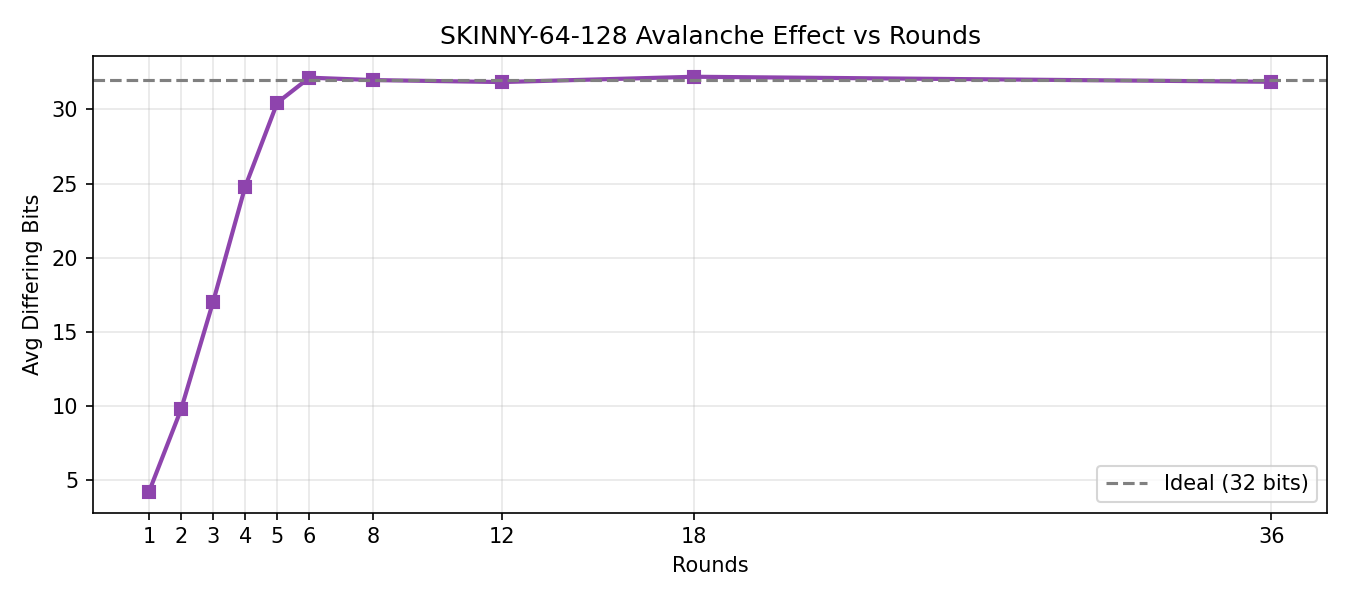

Saved : results_skinny\avalanche.png


In [7]:
import random as _rnd2
_rnd2.seed(0)

print('Computing avalanche effect ...')
avg_diffs = []
for r in ROUND_LIST:
    diffs = [
        bin(
            SkinnyCipher(KEY, r).encrypt(pt1 := _rnd2.randint(0, (1<<64)-1)) ^
            SkinnyCipher(KEY, r).encrypt(pt1 ^ (1 << _rnd2.randint(0, 63)))
        ).count('1')
        for _ in range(500)
    ]
    avg_diffs.append(sum(diffs) / len(diffs))
    print(f'  r={r:2d} | avg diff = {avg_diffs[-1]:.2f}/64')

plt.figure(figsize=(9, 4))
plt.plot(ROUND_LIST, avg_diffs, marker='s', color='#8e44ad', linewidth=2)
plt.axhline(32, color='gray', linestyle='--', label='Ideal (32 bits)')
plt.xlabel('Rounds'); plt.ylabel('Avg Differing Bits')
plt.title('SKINNY-64-128 Avalanche Effect vs Rounds')
plt.xticks(ROUND_LIST); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'avalanche.png')
plt.savefig(path, dpi=150); plt.close()
display(Image(path))
print(f'Saved : {path}')

### Logistic Regression

In [8]:
print('\n── Logistic Regression ──')
lr_results = {}
for r in ROUND_LIST:
    t0 = time.time()
    m  = LogisticRegressionModel()
    m.fit(datasets[r]['X_train'], datasets[r]['y_train'].astype(int))
    metrics = m.evaluate(datasets[r]['X_test'], datasets[r]['y_test'])
    metrics['train_time_s'] = round(time.time() - t0, 1)
    lr_results[r] = metrics
    print(f'  r={r:2d} | bitacc={metrics["bitwise_accuracy"]:.4f} '
          f'hamming={metrics["mean_hamming"]:.2f} '
          f'exact={metrics["exact_match"]:.4f} '
          f'time={metrics["train_time_s"]}s')


── Logistic Regression ──
  r= 1 | bitacc=0.5629 hamming=27.97 exact=0.0000 time=1.0s
  r= 2 | bitacc=0.5012 hamming=31.92 exact=0.0000 time=0.9s
  r= 3 | bitacc=0.5005 hamming=31.97 exact=0.0000 time=0.8s
  r= 4 | bitacc=0.4993 hamming=32.04 exact=0.0000 time=0.8s
  r= 5 | bitacc=0.5002 hamming=31.99 exact=0.0000 time=0.8s
  r= 6 | bitacc=0.4986 hamming=32.09 exact=0.0000 time=0.9s
  r= 8 | bitacc=0.4993 hamming=32.05 exact=0.0000 time=0.8s
  r=12 | bitacc=0.5008 hamming=31.95 exact=0.0000 time=0.8s
  r=18 | bitacc=0.4988 hamming=32.08 exact=0.0000 time=0.8s
  r=36 | bitacc=0.4999 hamming=32.01 exact=0.0000 time=0.8s


### MLP

In [9]:
print('\n── MLP ──')
mlp_results = {}
for r in ROUND_LIST:
    print(f'\n  rounds = {r}')
    m = MLPModel(epochs=EPOCHS, batch_size=BATCH_SIZE)
    t0 = time.time()
    m.fit(datasets[r]['X_train'], datasets[r]['y_train'],
          datasets[r]['X_val'],   datasets[r]['y_val'])
    metrics = m.evaluate(datasets[r]['X_test'], datasets[r]['y_test'])
    metrics['train_time_s'] = round(time.time() - t0, 1)
    mlp_results[r] = metrics
    if m.net:
        torch.save(m.net.state_dict(),
                   os.path.join(MODELS_DIR, f'mlp_r{r}.pt'))
    print(f'   bitacc={metrics["bitwise_accuracy"]:.4f} '
          f'hamming={metrics["mean_hamming"]:.2f}')


── MLP ──

  rounds = 1
    Epoch  10/50 | loss=0.5110 | val_bitacc=0.6808
    Epoch  20/50 | loss=0.4711 | val_bitacc=0.6948
    Epoch  30/50 | loss=0.4466 | val_bitacc=0.7080
    Epoch  40/50 | loss=0.4334 | val_bitacc=0.7155
    Epoch  50/50 | loss=0.4305 | val_bitacc=0.7172
   bitacc=0.7202 hamming=17.91

  rounds = 2
    Epoch  10/50 | loss=0.6851 | val_bitacc=0.5010
    Early stop at epoch 18 (best=0.5021)
   bitacc=0.5003 hamming=31.98

  rounds = 3
    Early stop at epoch 7 (best=0.5016)
   bitacc=0.4999 hamming=32.01

  rounds = 4
    Early stop at epoch 8 (best=0.5014)
   bitacc=0.4999 hamming=32.00

  rounds = 5
    Early stop at epoch 7 (best=0.5002)
   bitacc=0.5000 hamming=32.00

  rounds = 6
    Epoch  10/50 | loss=0.6853 | val_bitacc=0.5000
    Early stop at epoch 12 (best=0.5010)
   bitacc=0.4983 hamming=32.11

  rounds = 8
    Early stop at epoch 9 (best=0.5009)
   bitacc=0.4999 hamming=32.01

  rounds = 12
    Epoch  10/50 | loss=0.6851 | val_bitacc=0.4990
    Early

### CNN

In [10]:
print('\n── CNN ──')
cnn_results = {}
for r in ROUND_LIST:
    print(f'\n  rounds = {r}')
    m = CNNModel(epochs=EPOCHS, batch_size=BATCH_SIZE)
    t0 = time.time()
    m.fit(datasets[r]['X_train'], datasets[r]['y_train'],
          datasets[r]['X_val'],   datasets[r]['y_val'])
    metrics = m.evaluate(datasets[r]['X_test'], datasets[r]['y_test'])
    metrics['train_time_s'] = round(time.time() - t0, 1)
    cnn_results[r] = metrics
    if m.net:
        torch.save(m.net.state_dict(),
                   os.path.join(MODELS_DIR, f'cnn_r{r}.pt'))
    print(f'  --> bitacc={metrics["bitwise_accuracy"]:.4f} '
          f'hamming={metrics["mean_hamming"]:.2f}')

# Persist all results
all_results = {'lr': lr_results, 'mlp': mlp_results, 'cnn': cnn_results}



── CNN ──

  rounds = 1
    Epoch  10/50 | loss=0.5844 | val_bitacc=0.6076
    Epoch  20/50 | loss=0.5360 | val_bitacc=0.6248
    Early stop at epoch 25 (best=0.6258)
  --> bitacc=0.6253 hamming=23.98

  rounds = 2
    Early stop at epoch 7 (best=0.5002)
  --> bitacc=0.5000 hamming=32.00

  rounds = 3
    Epoch  10/50 | loss=0.6930 | val_bitacc=0.5006
    Early stop at epoch 10 (best=0.5014)
  --> bitacc=0.5000 hamming=32.00

  rounds = 4
    Epoch  10/50 | loss=0.6930 | val_bitacc=0.5012
    Early stop at epoch 12 (best=0.5021)
  --> bitacc=0.5000 hamming=32.00

  rounds = 5
    Early stop at epoch 7 (best=0.5023)
  --> bitacc=0.5003 hamming=31.98

  rounds = 6
    Epoch  10/50 | loss=0.6930 | val_bitacc=0.5002
    Epoch  20/50 | loss=0.6922 | val_bitacc=0.5014
    Early stop at epoch 27 (best=0.5020)
  --> bitacc=0.5004 hamming=31.98

  rounds = 8
    Early stop at epoch 8 (best=0.5022)
  --> bitacc=0.5008 hamming=31.95

  rounds = 12
    Epoch  10/50 | loss=0.6929 | val_bitacc=0.49

## 6  Results & Visualisation

### Bitwise Accuracy

In [11]:
print('\n' + '='*65)
print('  SKINNY-64-128  BITWISE ACCURACY SUMMARY')
print(f'  {"Rounds":>8}  {"LogReg":>10}  {"MLP":>10}  {"CNN":>10}')
print('-'*65)
for r in ROUND_LIST:
    la = lr_results[r]['bitwise_accuracy']
    ma = mlp_results[r]['bitwise_accuracy']
    ca = cnn_results[r]['bitwise_accuracy']
    print(f'  {r:>8}  {la:>10.4f}  {ma:>10.4f}  {ca:>10.4f}')
print('='*65)

print('\nLearnability threshold (bitacc > 0.55):')
for key_, res in all_results.items():
    learnable = [r for r in ROUND_LIST if res[r]['bitwise_accuracy'] > LEARN_THRESHOLD]
    print(f'  {LABELS[key_]:25s}: max learnable r = {max(learnable) if learnable else 0}')


  SKINNY-64-128  BITWISE ACCURACY SUMMARY
    Rounds      LogReg         MLP         CNN
-----------------------------------------------------------------
         1      0.5629      0.7202      0.6253
         2      0.5012      0.5003      0.5000
         3      0.5005      0.4999      0.5000
         4      0.4993      0.4999      0.5000
         5      0.5002      0.5000      0.5003
         6      0.4986      0.4983      0.5004
         8      0.4993      0.4999      0.5008
        12      0.5008      0.4997      0.4990
        18      0.4988      0.5003      0.5004
        36      0.4999      0.5001      0.5015

Learnability threshold (bitacc > 0.55):
  Logistic Regression      : max learnable r = 1
  MLP                      : max learnable r = 1
  CNN                      : max learnable r = 1


### Combined Metrics Plot

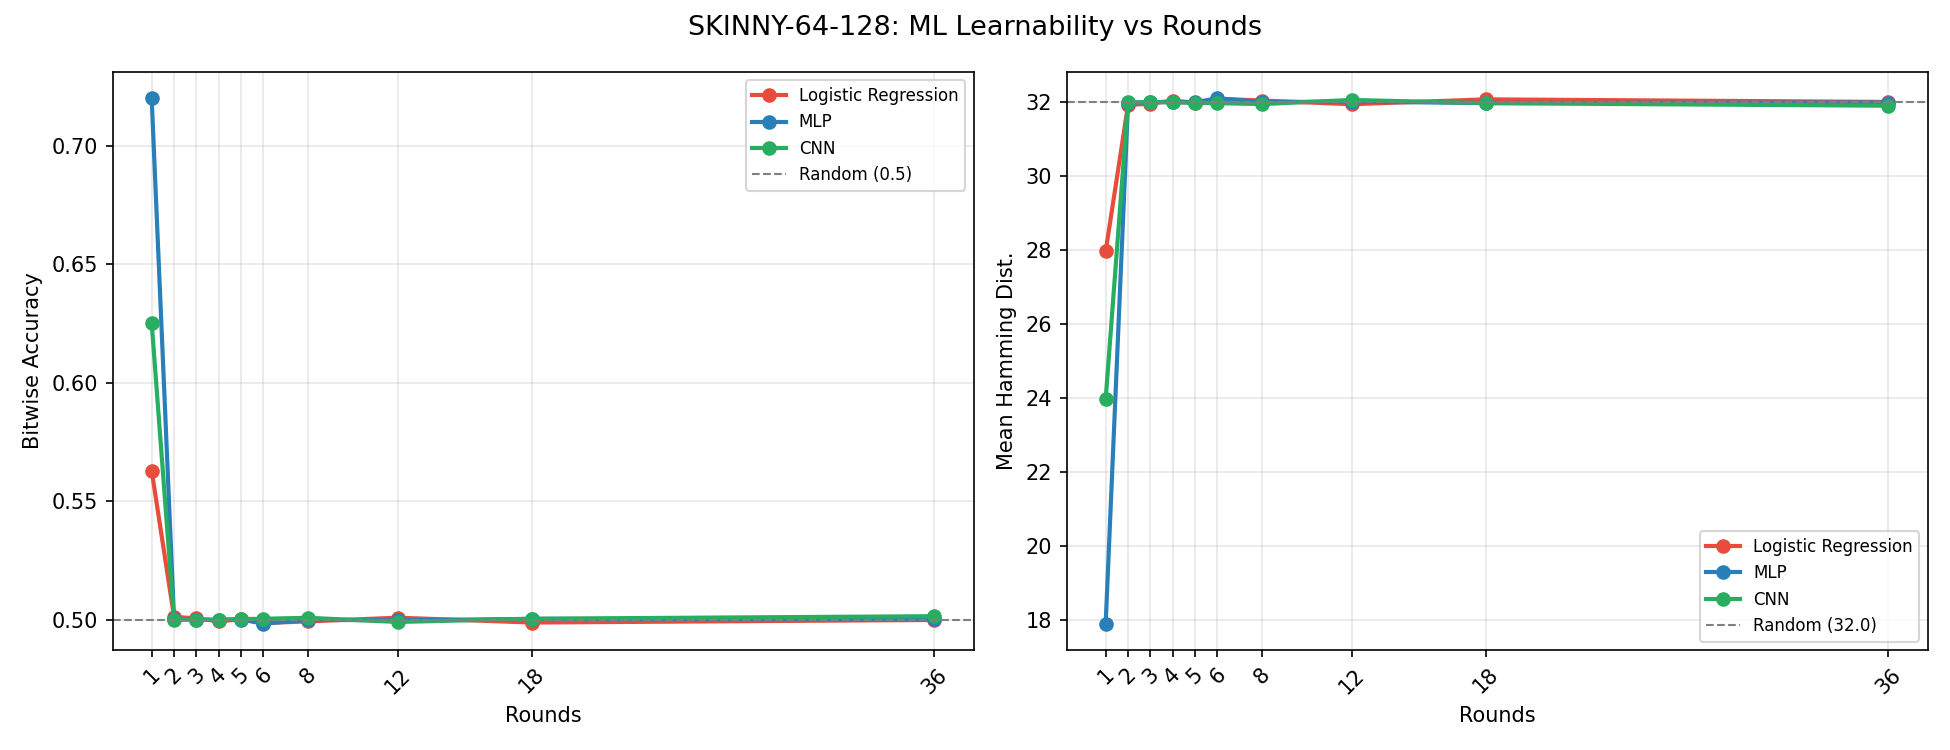

Saved → results_skinny\combined_metrics.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metric_cfg = [
    ('bitwise_accuracy', 'Bitwise Accuracy',   RANDOM_BITACC),
    ('mean_hamming',     'Mean Hamming Dist.',  RANDOM_HAMMING),
]

for ax, (metric, ylabel, hline) in zip(axes, metric_cfg):
    for m, res in all_results.items():
        ax.plot(ROUND_LIST, [res[r][metric] for r in ROUND_LIST],
                marker='o', linewidth=2, color=COLORS[m], label=LABELS[m])
    if hline is not None:
        ax.axhline(hline, color='gray', linestyle='--', linewidth=1,
                   label=f'Random ({hline})')
    ax.set_xlabel('Rounds'); ax.set_ylabel(ylabel)
    ax.set_xticks(ROUND_LIST); ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('SKINNY-64-128: ML Learnability vs Rounds', fontsize=13)
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'combined_metrics.png')
plt.savefig(path, dpi=150); plt.close()
display(Image(path))
print(f'Saved → {path}')


## 7  Generalisation Test (Unseen Plaintexts)

Tests whether the trained MLP actually learnt cipher structure  
or merely memorised training pairs.  
Uses **seed=999** — guaranteed fresh plaintexts (training used seed=42).

In [13]:

NEW_SEED    = 999
NEW_SAMPLES = 5_000

def load_mlp(r):
    path = os.path.join(MODELS_DIR, f'mlp_r{r}.pt')
    if not os.path.exists(path):
        return None
    m = MLPNet().to(DEVICE)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    return m


@torch.no_grad()
def predict_gen(model, X):
    Xt   = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    prob = torch.sigmoid(model(Xt)).cpu().numpy()
    return (prob >= 0.5).astype(np.float32), prob



print('='*60)
print('  Generalisation Test (Unseen Plaintexts)')
print('='*60)
gen_results = {}

for r in ROUND_LIST:
    print(f'\n── r = {r}')
    X_new, y_new = generate_dataset(
        num_rounds=r, num_samples=NEW_SAMPLES,
        key=KEY, seed=NEW_SEED,
        cache_dir='data/cache_skinny_gen',
    )
    model = load_mlp(r)
    if model is None:
        print(f'  No checkpoint — skipping r={r}')
        continue

    y_pred, prob = predict_gen(model, X_new)
    bitacc  = float(np.mean(y_pred == y_new))
    hamming_d = float(np.mean(np.sum(np.abs(y_pred - y_new), axis=1)))
    exact   = float(np.mean(np.all(y_pred == y_new, axis=1)))

    gen_results[r] = {'bitwise_accuracy': bitacc,
                      'mean_hamming': hamming_d,
                      'exact_match': exact}

    print(f'  Bitwise accuracy : {bitacc:.4f}  (+{bitacc-0.5:+.4f} vs random)')
    print(f'  Mean Hamming     : {hamming_d:.2f} / 64')
    print(f'  Exact match      : {exact:.6f}')


  Generalisation Test (Unseen Plaintexts)

── r = 1
[Dataset] Loaded from cache: data/cache_skinny_gen\skinny_r1_685aa355e8.pkl
  Bitwise accuracy : 0.7192  (++0.2192 vs random)
  Mean Hamming     : 17.97 / 64
  Exact match      : 0.000000

── r = 2
[Dataset] Loaded from cache: data/cache_skinny_gen\skinny_r2_a07830af91.pkl
  Bitwise accuracy : 0.4995  (+-0.0005 vs random)
  Mean Hamming     : 32.03 / 64
  Exact match      : 0.000000

── r = 3
[Dataset] Loaded from cache: data/cache_skinny_gen\skinny_r3_3ceb7f907a.pkl
  Bitwise accuracy : 0.4993  (+-0.0007 vs random)
  Mean Hamming     : 32.04 / 64
  Exact match      : 0.000000

── r = 4
[Dataset] Loaded from cache: data/cache_skinny_gen\skinny_r4_85d5d2a0d8.pkl
  Bitwise accuracy : 0.4995  (+-0.0005 vs random)
  Mean Hamming     : 32.03 / 64
  Exact match      : 0.000000

── r = 5
[Dataset] Loaded from cache: data/cache_skinny_gen\skinny_r5_25cd506221.pkl
  Bitwise accuracy : 0.4977  (+-0.0023 vs random)
  Mean Hamming     : 32.15 / 6

### Train vs Generalisation Comparison

In [14]:
if gen_results:
    print('\n  TRAIN (test split) vs GENERALISATION — MLP')
    print(f'  {"─"*52}')
    print(f'  {"Rounds":>8}  {"Train BitAcc":>13}  {"Gen BitAcc":>11}  {"Gap":>6}')
    print(f'  {"─"*52}')
    for r in ROUND_LIST:
        if r not in gen_results:
            continue
        tr = mlp_results[r]['bitwise_accuracy']
        ge = gen_results[r]['bitwise_accuracy']
        print(f'  {r:>8}  {tr:>13.4f}  {ge:>11.4f}  {tr-ge:>+6.4f}')
    print('\n  Gap ~ 0 : model learnt cipher structure, not memorisation.')


  TRAIN (test split) vs GENERALISATION — MLP
  ────────────────────────────────────────────────────
    Rounds   Train BitAcc   Gen BitAcc     Gap
  ────────────────────────────────────────────────────
         1         0.7202       0.7192  +0.0009
         2         0.5003       0.4995  +0.0008
         3         0.4999       0.4993  +0.0006
         4         0.4999       0.4995  +0.0004
         5         0.5000       0.4977  +0.0023
         6         0.4983       0.5000  -0.0016
         8         0.4999       0.5002  -0.0003
        12         0.4997       0.5015  -0.0018
        18         0.5003       0.5006  -0.0003
        36         0.5001       0.4988  +0.0013

  Gap ~ 0 : model learnt cipher structure, not memorisation.


## 8  Final Summary



In [15]:
print('\n' + '='*70)
print('  SKINNY-64-128  COMPLETE RESULTS SUMMARY')
print('='*70)
print(f'  {"Rounds":>8}  {"LR BitAcc":>10}  {"MLP BitAcc":>11}  '
      f'{"CNN BitAcc":>11}  {"MLP Hamming":>12}  {"Gen BitAcc":>11}')
print('-'*70)
for r in ROUND_LIST:
    la  = lr_results[r]['bitwise_accuracy']
    ma  = mlp_results[r]['bitwise_accuracy']
    ca  = cnn_results[r]['bitwise_accuracy']
    mh  = mlp_results[r]['mean_hamming']
    ga  = gen_results.get(r, {}).get('bitwise_accuracy', float('nan'))
    print(f'  {r:>8}  {la:>10.4f}  {ma:>11.4f}  {ca:>11.4f}  '
          f'{mh:>12.2f}  {ga:>11.4f}')
print('='*70)



  SKINNY-64-128  COMPLETE RESULTS SUMMARY
    Rounds   LR BitAcc   MLP BitAcc   CNN BitAcc   MLP Hamming   Gen BitAcc
----------------------------------------------------------------------
         1      0.5629       0.7202       0.6253         17.91       0.7192
         2      0.5012       0.5003       0.5000         31.98       0.4995
         3      0.5005       0.4999       0.5000         32.01       0.4993
         4      0.4993       0.4999       0.5000         32.00       0.4995
         5      0.5002       0.5000       0.5003         32.00       0.4977
         6      0.4986       0.4983       0.5004         32.11       0.5000
         8      0.4993       0.4999       0.5008         32.01       0.5002
        12      0.5008       0.4997       0.4990         32.02       0.5015
        18      0.4988       0.5003       0.5004         31.98       0.5006
        36      0.4999       0.5001       0.5015         31.99       0.4988
